# 🔋 Battery Remaining Useful Life (RUL) Prediction using Machine Learning
## Predicting Battery Remaining Useful Life using NASA Battery Aging Dataset

## 📖 Project Overview

Battery Remaining Useful Life (RUL) prediction is an important predictive maintenance task in electric vehicles, renewable energy systems, and battery management systems (BMS). This project uses the NASA Battery Aging Dataset to build machine learning models that estimate the remaining number of battery cycles before end-of-life.

Multiple regression algorithms are compared, hyperparameter tuning is performed, and the best model is evaluated using standard regression metrics.

## 1. Problem Definition

The goal of this project is to predict the Remaining Useful Life (RUL) of lithium-ion batteries using machine learning techniques.

Remaining Useful Life (RUL) represents the number of discharge cycles left before a battery reaches the end of its useful life. Accurate RUL prediction is essential for predictive maintenance, battery management systems (BMS), electric vehicles, and energy storage applications.

Using battery operational data such as cycle number, capacity, average voltage, average current, average temperature, and discharge time, this project develops regression models capable of estimating battery RUL.

## 2. Data

The dataset is derived from the NASA Battery Aging Dataset. Raw MATLAB (.mat) files were processed to extract discharge cycle information, battery capacity, voltage, current, temperature, and discharge duration.

After preprocessing:
- Exact duplicate records were removed.
- Invalid capacity values (0 Ah) were excluded.
- Remaining Useful Life (RUL) was calculated for every discharge cycle.

Final dataset contains 2,750 discharge cycles collected from multiple lithium-ion batteries.

## 3. Evaluation

The objective is to build a regression model that accurately predicts battery Remaining Useful Life (RUL).

Model performance will be evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The best model is selected based on lower MAE and RMSE values along with a higher R² score.

## 4. Features

Input Features:

- Cycle
- Capacity
- Avg_Voltage
- Avg_Current
- Avg_Temperature
- Discharge_Time

Target Variable:

- RUL (Remaining Useful Life)

Identifier:

- Battery_ID

## 5. Modelling

The following regression algorithms will be evaluated:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor

## 6. Experimentation

The project workflow includes:

- Data Inspection
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Model Training
- Model Evaluation
- Hyperparameter Tuning
- Cross Validation
- Feature Importance
- Actual vs Predicted Analysis
- Residual Analysis

In [1]:
# Import tools that we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Models from Scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Model Selection
from sklearn.model_selection import train_test_split, cross_val_score

# Evaluation Matrics
from sklearn.metrics import (
     mean_absolute_error,
     mean_squared_error,
     r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")


In [2]:
# Load Dataset
battery_df = pd.read_csv("battery_rul_dataset_clean.csv")

print("Dataset Shape:", battery_df.shape)
battery_df.head()

Dataset Shape: (2750, 8)


,Battery_ID,Cycle,Capacity,Avg_Voltage,Avg_Current,Avg_Temperature,Discharge_Time,RUL
0,B0005,1,1.856487,3.529829,-1.818702,32.572328,3690.234,167
1,B0005,2,1.846327,3.537320,-1.817560,32.725235,3672.344,166
2,B0005,3,1.835349,3.543737,-1.816487,32.642862,3651.641,165
3,B0005,4,1.835263,3.543666,-1.825589,32.514876,3631.563,164
4,B0005,5,1.834646,3.542343,-1.826114,32.382349,3629.172,163


In [3]:
battery_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2750 entries, 0 to 2749
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Battery_ID       2750 non-null   str    
 1   Cycle            2750 non-null   int64  
 2   Capacity         2750 non-null   float64
 3   Avg_Voltage      2750 non-null   float64
 4   Avg_Current      2750 non-null   float64
 5   Avg_Temperature  2750 non-null   float64
 6   Discharge_Time   2750 non-null   float64
 7   RUL              2750 non-null   int64  
dtypes: float64(5), int64(2), str(1)
memory usage: 172.0 KB


In [4]:
battery_df.describe()

,Cycle,Capacity,Avg_Voltage,Avg_Current,Avg_Temperature,Discharge_Time,RUL
count,2750.000000,2750.000000,2750.000000,2750.000000,2750.000000,2750.000000,2750.000000
mean,60.928000,1.335708,3.430096,-1.732109,27.070622,3236.721989,59.961091
std,48.382245,0.461052,0.198000,0.782199,13.847814,1385.954574,48.323373
min,1.000000,0.032558,2.530010,-3.976473,4.857764,96.484000,0.000000
25%,22.000000,1.156433,3.367181,-1.944707,11.723473,2530.761750,21.000000
50%,48.000000,1.430577,3.415655,-1.796395,31.378623,3033.625000,47.000000
75%,91.000000,1.674432,3.490193,-1.063812,34.351356,3390.281000,90.000000
max,197.000000,2.640149,4.452558,-0.029284,58.954811,6574.671000,196.000000


In [5]:
battery_df.isnull().sum()

Battery_ID         0
Cycle              0
Capacity           0
Avg_Voltage        0
Avg_Current        0
Avg_Temperature    0
Discharge_Time     0
RUL                0
dtype: int64

In [6]:
battery_df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)

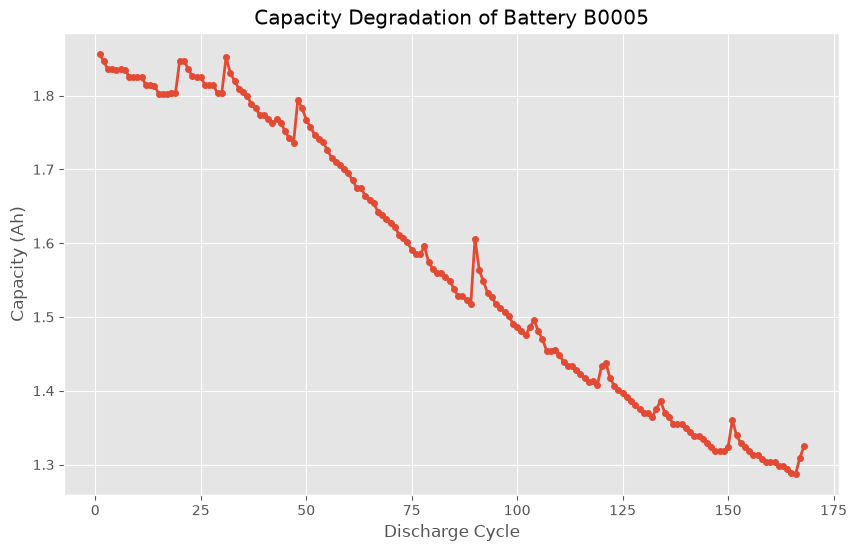

In [7]:
# Capacity Degradation Curve

plt.figure(figsize=(10,6))

battery = battery_df[battery_df["Battery_ID"] == "B0005"]

plt.plot(
    battery["Cycle"],
    battery["Capacity"],
    marker="o",
    markersize=4,
    linewidth=2
)

plt.title("Capacity Degradation of Battery B0005")
plt.xlabel("Discharge Cycle")
plt.ylabel("Capacity (Ah)")
plt.grid(True)

plt.show()

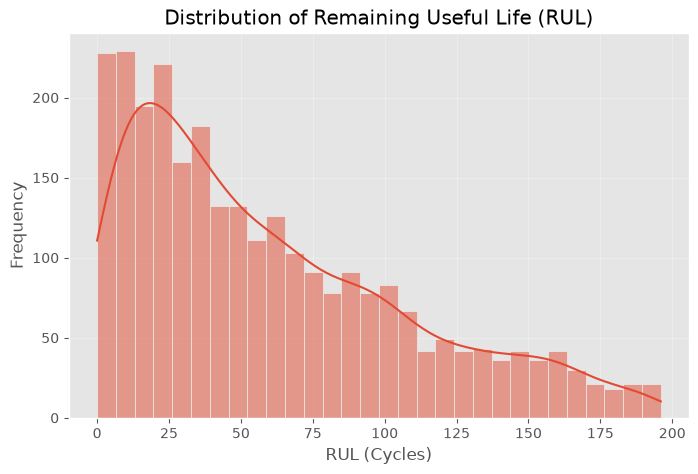

In [8]:
# Distribution of RUl
plt.figure(figsize=(8,5))

sns.histplot(battery_df["RUL"], bins=30, kde=True)

plt.title("Distribution of Remaining Useful Life (RUL)")
plt.xlabel("RUL (Cycles)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.show()

The Remaining Useful Life (RUL) distribution is right-skewed, with most samples having lower RUL values and fewer samples having higher RUL values. This indicates that the dataset contains more observations from batteries approaching the end of their life. The target variable does not show abnormal peaks or missing ranges.

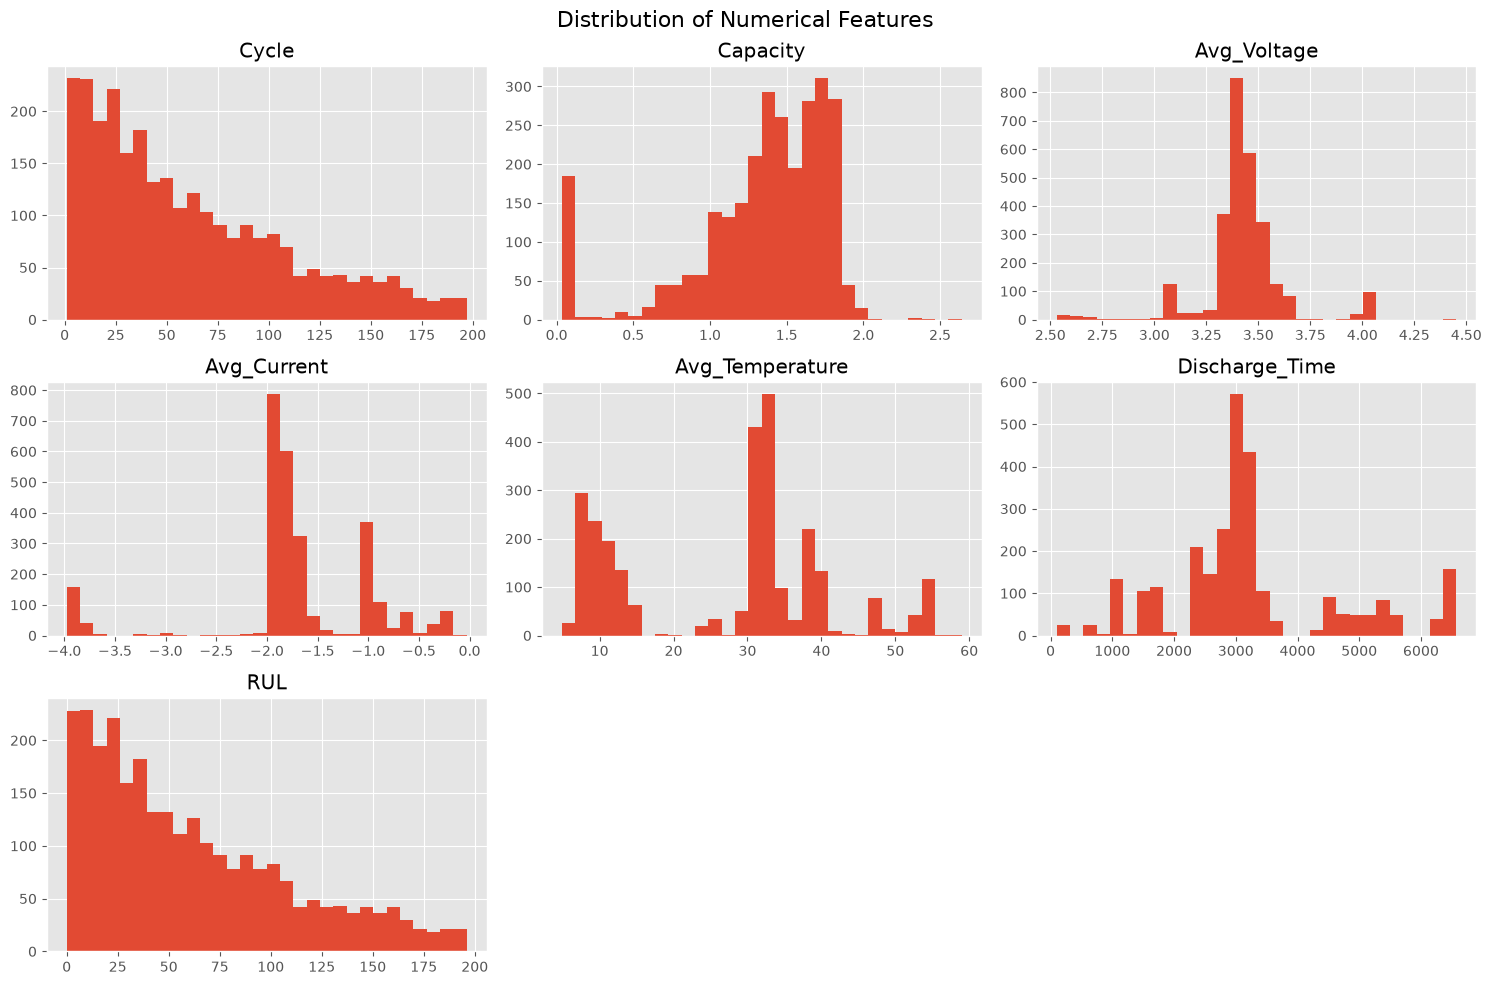

In [9]:
# Distribution of all Numerical Features
battery_df.hist(figsize=(15,10), bins=30)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()

plt.show()


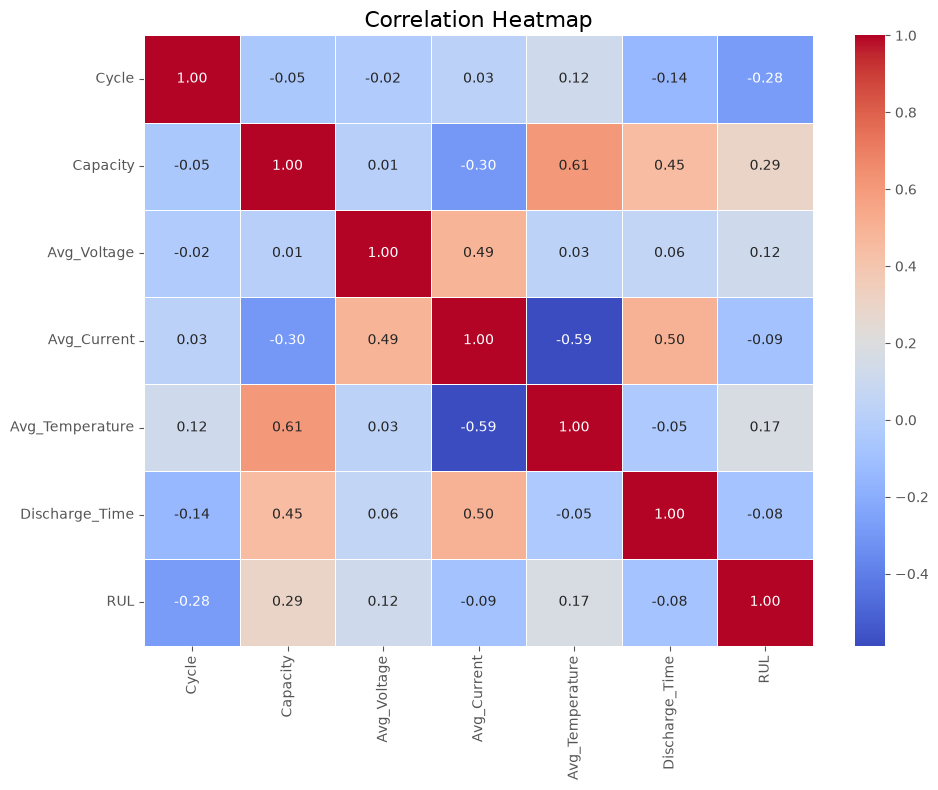

In [10]:
# Correlation Heatmap

plt.figure(figsize=(10, 8))

corr_matrix = battery_df.drop(columns=["Battery_ID"]).corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size": 10}
)

plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

The correlation heatmap shows that Capacity has the strongest positive correlation with Remaining Useful Life (RUL), while Cycle has the strongest negative correlation, making them the most informative features for RUL prediction. The remaining features exhibit weak linear correlations with RUL but may still contribute through non-linear relationships that tree-based machine learning models can capture.

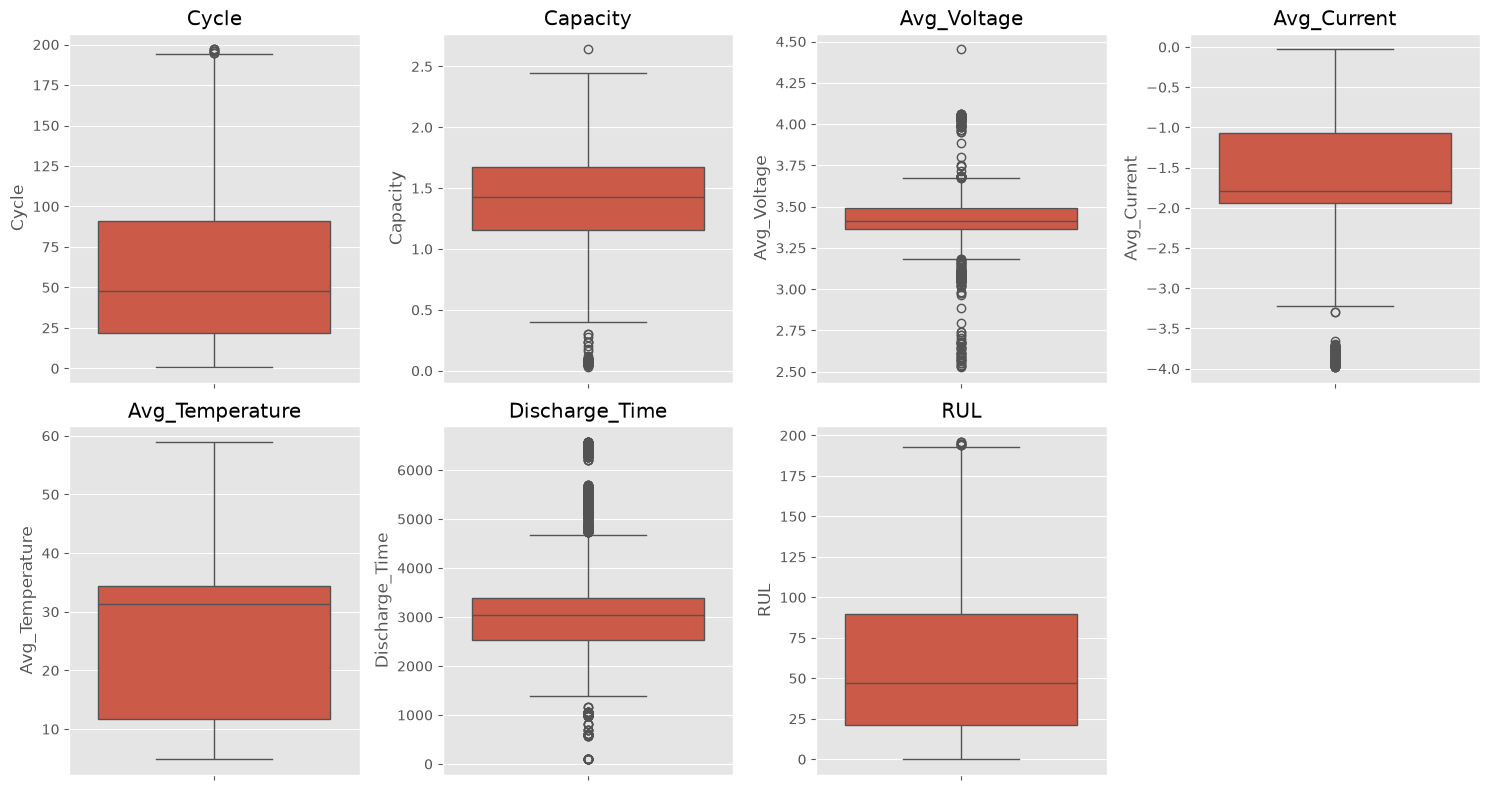

In [11]:
# Boxplot 
plt.figure(figsize=(15,8))

numerical_columns = [
    "Cycle",
    "Capacity",
    "Avg_Voltage",
    "Avg_Current",
    "Avg_Temperature",
    "Discharge_Time",
    "RUL"
]

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=battery_df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

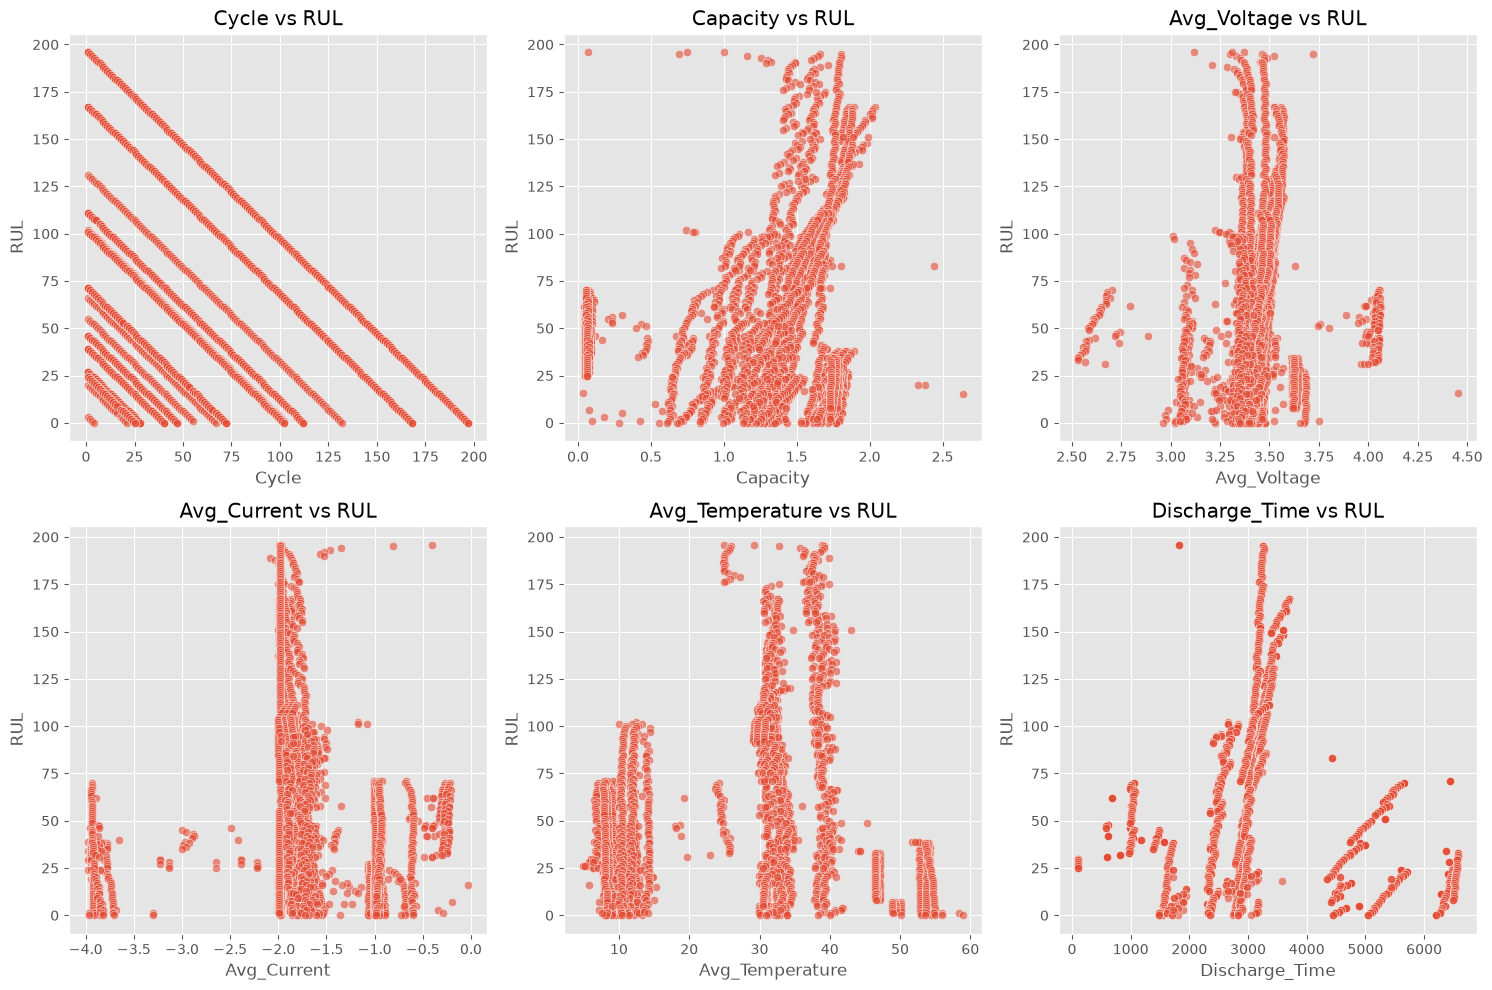

In [12]:
# Feature vs RUL
plt.figure(figsize=(15,10))

features = [
    "Cycle",
    "Capacity",
    "Avg_Voltage",
    "Avg_Current",
    "Avg_Temperature",
    "Discharge_Time"
]

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)

    sns.scatterplot(
        data=battery_df,
        x=feature,
        y="RUL",
        alpha=0.6
    )

    plt.title(f"{feature} vs RUL")

plt.tight_layout()
plt.show()

Exploratory Data Analysis indicates that Cycle and Capacity have the strongest relationships with Remaining Useful Life (RUL). Discharge Time also shows a noticeable trend, while Average Voltage, Average Current, and Average Temperature exhibit weaker individual relationships. Despite their weaker linear relationships, these features will be retained because ensemble models such as Random Forest and XGBoost can capture complex non-linear interactions.

## Feature Selection

In [13]:
# Inpute features
X = battery_df.drop(columns=["Battery_ID", "RUL"])

# Target variable
y = battery_df["RUL"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

X.head()

Feature Shape: (2750, 6)
Target Shape: (2750,)


,Cycle,Capacity,Avg_Voltage,Avg_Current,Avg_Temperature,Discharge_Time
0,1,1.856487,3.529829,-1.818702,32.572328,3690.234
1,2,1.846327,3.537320,-1.817560,32.725235,3672.344
2,3,1.835349,3.543737,-1.816487,32.642862,3651.641
3,4,1.835263,3.543666,-1.825589,32.514876,3631.563
4,5,1.834646,3.542343,-1.826114,32.382349,3629.172


## Train-Test Split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Feature:", X_train.shape)
print("Testing Feature:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:",  y_test.shape)

Training Feature: (2200, 6)
Testing Feature: (550, 6)
Training Target: (2200,)
Testing Target: (550,)


### Linear Regression Model

In [15]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ -0.46, 95.11,-83.53, 63.48, 0.82, -0.04]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['Cycle','Capacity','Avg_Voltage','Avg_Current','Avg_Temperature', 'Discharge_Time']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,454
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [16]:
# Predict RUL on test data
y_pred_lr = lr_model.predict(X_test)

comparison = pd.DataFrame({
    "Actual RUL": y_test.values,
    "Predicted RUL": y_pred_lr
})

comparison.head(10)

,Actual RUL,Predicted RUL
0,99,68.863524
1,126,81.780969
2,11,40.717028
3,16,35.569914
4,108,95.855787
5,18,69.490680
6,10,38.059930
7,0,20.581764
8,139,97.083753
9,29,71.968854


In [17]:
# Eveluate the Model

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("-" * 35)
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2  : {r2:.4f}")

Linear Regression Performance
-----------------------------------
MAE : 28.7185
MSE : 1353.6355
RMSE: 36.7918
R2  : 0.3546


Linear Regression was selected as the baseline model for Remaining Useful Life (RUL) prediction. The model achieved an MAE of 28.72 cycles, an RMSE of 36.79 cycles, and an R² score of 0.3546. These results indicate that Linear Regression explains only about 35% of the variance in the target variable. The relatively high prediction errors suggest that the relationship between battery features and RUL is non-linear, motivating the use of more advanced machine learning algorithms such as Decision Tree, Random Forest, Gradient Boosting, and XGBoost.

### Decision Tree Regressor

In [18]:
from sklearn.tree import DecisionTreeRegressor

In [19]:
decision_tree = DecisionTreeRegressor(
    random_state=42
)

decision_tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [20]:
y_pred_dt = decision_tree.predict(
    X_test
)

In [21]:
comparison_dt = pd.DataFrame()

comparison_dt["Actual RUL"] = y_test.values
comparison_dt["Predicted RUL"] = y_pred_dt

comparison_dt.head(10)

,Actual RUL,Predicted RUL
0,99,99.0
1,126,126.0
2,11,11.0
3,16,16.0
4,108,109.0
5,18,18.0
6,10,10.0
7,0,0.0
8,139,139.0
9,29,29.0


In [22]:
# Model Evaluation

mae = mean_absolute_error(y_test, y_pred_dt)
mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("-" * 35)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2  : {r2:.4f}")

Decision Tree Performance
-----------------------------------
MAE : 2.3836
MSE : 163.5509
RMSE: 12.7887
R2  : 0.9220


The Decision Tree Regressor significantly outperformed the Linear Regression model. It achieved an MAE of 2.38 cycles, an RMSE of 12.79 cycles, and an R² score of 0.9220, explaining over 92% of the variance in the Remaining Useful Life (RUL). This improvement indicates that the relationship between battery operating parameters and RUL is highly non-linear, making Decision Trees more suitable than linear models for this prediction task.

### Random Forest Regressor

In [23]:
from sklearn.ensemble import RandomForestRegressor

In [24]:
random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [25]:
random_forest.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [26]:
y_pred_rf = random_forest.predict(
    X_test
)

In [27]:
comparison_rf = pd.DataFrame()

comparison_rf["Actual RUL"] = y_test.values
comparison_rf["Predicted RUL"] = y_pred_rf

comparison_rf.head(10)

,Actual RUL,Predicted RUL
0,99,98.21
1,126,125.77
2,11,11.01
3,16,15.98
4,108,108.63
5,18,18.42
6,10,10.44
7,0,1.42
8,139,134.54
9,29,28.94


In [28]:
# Model evaluation

mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse= np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Preformance")
print("-" * 35)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

Random Forest Preformance
-----------------------------------
MAE  : 2.5151
MSE  : 75.8331
RMSE : 8.7082
R2   : 0.9638


The Random Forest Regressor achieved the best performance so far, with an MAE of 2.52 cycles, an RMSE of 8.71 cycles, and an R² score of 0.9638. Compared to the Decision Tree, the Random Forest reduced large prediction errors and improved the overall model fit. These results demonstrate that ensemble learning provides more accurate and robust predictions for Remaining Useful Life (RUL).

### Gradient Boosting Regressor

In [29]:
from sklearn.ensemble import GradientBoostingRegressor

In [30]:
gradient_boosting = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.1,
    random_state=42
)

In [31]:
gradient_boosting.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [32]:
y_pred_gb = gradient_boosting.predict(
    X_test
)

In [33]:
comparison_gb = pd.DataFrame()

comparison_gb["Actual RUL"] = y_test.values
comparison_gb["Predicted RUL"] = y_pred_gb

comparison_gb.head(10)

,Actual RUL,Predicted RUL
0,99,96.562884
1,126,125.281062
2,11,10.991240
3,16,14.230538
4,108,110.017409
5,18,19.947107
6,10,13.916798
7,0,2.507857
8,139,131.596935
9,29,26.913143


In [34]:
# Model evaluation

mae = mean_absolute_error(y_test, y_pred_gb)
mse = mean_squared_error(y_test, y_pred_gb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Performance")
print("-" * 35)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

Gradient Boosting Performance
-----------------------------------
MAE  : 4.4826
MSE  : 87.6798
RMSE : 9.3637
R2   : 0.9582


The Gradient Boosting Regressor was initially trained with the default setting of 100 estimators. To improve performance, the number of estimators was increased to 300. This reduced the MAE from 7.13 to 4.48, reduced the RMSE from 13.47 to 9.36, and increased the R² score from 0.9135 to 0.9582, demonstrating that tuning the number of boosting stages significantly improved prediction accuracy.

### XGBoost Regressor

In [35]:
from xgboost import XGBRegressor

In [36]:
xgboost = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [37]:
xgboost.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [38]:
y_pred_xgb = xgboost.predict(X_test)

In [39]:
comparison_xgb = pd.DataFrame()

comparison_xgb["Actual RUL"] = y_test.values
comparison_xgb["Predicted RUL"] = y_pred_xgb

comparison_xgb.head(10)

,Actual RUL,Predicted RUL
0,99,98.296295
1,126,126.034012
2,11,10.085007
3,16,15.255491
4,108,123.429176
5,18,17.782438
6,10,10.684543
7,0,2.153845
8,139,137.274338
9,29,29.474514


In [40]:
# Model evaluation

mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance")
print("-" * 35)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

XGBoost Performance
-----------------------------------
MAE  : 2.9507
MSE  : 52.1513
RMSE : 7.2216
R2   : 0.9751


The XGBoost Regressor achieved the best overall performance for Remaining Useful Life (RUL) prediction, with an MAE of 2.95 cycles, an RMSE of 7.22 cycles, and an R² score of 0.9751. Compared to the other models, XGBoost produced the lowest prediction error and explained over 97% of the variation in the target variable. These results indicate that XGBoost is the most suitable model for this battery RUL prediction task.

### Extra Trees Regressor

In [41]:
from sklearn.ensemble import ExtraTreesRegressor

et_model = ExtraTreesRegressor(
    n_estimators= 100,
    random_state= 42,
    n_jobs= -1
)
et_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls 3 sources of randomness:- the bootstrapping of the samples used when building trees (if ``bootstrap=True``)- the sampling of the features to consider when looking for the best split at each node (if ``max_features < n_features``)- the draw of the splits for each of the `max_features`See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` f

In [42]:
y_pred_et = et_model.predict(X_test)

In [43]:
mae = mean_absolute_error(y_test, y_pred_et)
mse = mean_squared_error(y_test, y_pred_et)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_et)

print("Extra Trees Performance")
print("-" * 35)
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2  : {r2  :.4f}")

Extra Trees Performance
-----------------------------------
MAE : 1.2582
MSE : 24.8183
RMSE: 4.9818
R2  : 0.9882


## Model Comparison

In [44]:
model_comparison = pd.DataFrame()

model_comparison["Model"] = [
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting (100)",
    "Gradient Boosting (300)",
    "XGBoost",
    "Extra Trees"
]

model_comparison["MAE"] = [
    28.7185,
    2.3836,
    2.5151,
    7.1321,
    4.4826,
    2.9507,
    1.2582
]

model_comparison["MSE"] = [
    1353.6355,
    163.5509,
    75.8331,
    181.4892,
    87.6798,
    52.1513,
    24.8183
    
]

model_comparison["RMSE"] = [
    36.7918,
    12.7887,
    8.7082,
    13.4718,
    9.3637,
    7.2216,
    4.9818
]

model_comparison["R2 Score"] = [
    0.3546,
    0.9220,
    0.9638,
    0.9135,
    0.9582,
    0.9751,
    0.9882
]
model_comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,28.7185,1353.6355,36.7918,0.3546
1,Decision Tree,2.3836,163.5509,12.7887,0.9220
2,Random Forest,2.5151,75.8331,8.7082,0.9638
3,Gradient Boosting (100),7.1321,181.4892,13.4718,0.9135
4,Gradient Boosting (300),4.4826,87.6798,9.3637,0.9582
5,XGBoost,2.9507,52.1513,7.2216,0.9751
6,Extra Trees,1.2582,24.8183,4.9818,0.9882


In [45]:
best_model = model_comparison.loc[
    model_comparison["R2 Score"].idxmax()
]

best_model

Model       Extra Trees
MAE              1.2582
MSE             24.8183
RMSE             4.9818
R2 Score         0.9882
Name: 6, dtype: object

### Battery-wise split

In [46]:
battery_df["Battery_ID"].nunique()

34

In [47]:
battery_df["Battery_ID"].unique()

<StringArray>
['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028',
 'B0029', 'B0030', 'B0031', 'B0032', 'B0033', 'B0034', 'B0036', 'B0038',
 'B0039', 'B0040', 'B0041', 'B0042', 'B0043', 'B0044', 'B0045', 'B0046',
 'B0047', 'B0048', 'B0049', 'B0050', 'B0051', 'B0052', 'B0053', 'B0054',
 'B0055', 'B0056']
Length: 34, dtype: str

In [48]:
# battery-wise train_test_split

from sklearn.model_selection import train_test_split

battery_ids = battery_df["Battery_ID"].unique()

train_batteries, test_batteries = train_test_split(
    battery_ids,
    test_size=0.2,
    random_state=42
)

print("Training batteries:", len(train_batteries))
print("Testing batteries:", len(test_batteries))

print("\nTrain batteries:")
print(train_batteries)

print("\nTest batteries:")
print(test_batteries)

Training batteries: 27
Testing batteries: 7

Train batteries:
<StringArray>
['B0033', 'B0055', 'B0030', 'B0005', 'B0025', 'B0039', 'B0040', 'B0026',
 'B0034', 'B0032', 'B0006', 'B0007', 'B0053', 'B0018', 'B0052', 'B0046',
 'B0054', 'B0045', 'B0041', 'B0048', 'B0027', 'B0043', 'B0056', 'B0028',
 'B0031', 'B0036', 'B0051']
Length: 27, dtype: str

Test batteries:
<StringArray>
['B0038', 'B0042', 'B0050', 'B0049', 'B0029', 'B0047', 'B0044']
Length: 7, dtype: str


In [49]:
# Create train and test DataFrames

train_df = battery_df[battery_df["Battery_ID"].isin(train_batteries)]
test_df = battery_df[battery_df["Battery_ID"].isin(test_batteries)]

print("Training data:", train_df.shape)
print("Testing data:", test_df.shape)

Training data: (2328, 8)
Testing data: (422, 8)


In [50]:
# Create X/y

X_train_battery = train_df.drop(columns=["Battery_ID", "RUL"])
y_train_battery = train_df["RUL"]

X_test_battery = test_df.drop(columns=["Battery_ID", "RUL"])
y_test_battery = test_df["RUL"]

print("X_train:", X_train_battery.shape)
print("X_test :", X_test_battery.shape)

X_train: (2328, 6)
X_test : (422, 6)


In [51]:
from sklearn.ensemble import ExtraTreesRegressor

et_model_battery = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

et_model_battery.fit(X_train_battery, y_train_battery)

y_pred_et_battery = et_model_battery.predict(X_test_battery)

In [52]:
mae = mean_absolute_error(y_test_battery, y_pred_et_battery)
mse = mean_squared_error(y_test_battery, y_pred_et_battery)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_battery, y_pred_et_battery)

print("Extra Trees - Battery-wise Performance")
print("-" * 40)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 : {r2:.4f}")

Extra Trees - Battery-wise Performance
----------------------------------------
MAE : 10.0039
MSE : 355.7510
RMSE: 18.8614
R2 : 0.6176


In [53]:
# Battery-wise RUL statistics

battery_df.groupby("Battery_ID")["RUL"].agg(
    ["min", "max", "mean", "std", "count"]
).round(2)

,min,max,mean,std,count
Battery_ID,,,,,
B0005,0,167,83.50,48.64,168
B0006,0,167,83.50,48.64,168
B0007,0,167,83.50,48.64,168
B0018,0,131,65.50,38.25,132
B0025,0,27,13.50,8.23,28
B0026,0,27,13.50,8.23,28
B0027,0,27,13.50,8.23,28
B0028,0,27,13.50,8.23,28
B0029,0,39,19.50,11.69,40


In [54]:
# Actual train/test battery distribution

print("Training batteries:")
print(train_df.groupby("Battery_ID")["RUL"].max().sort_values())

print("\nTesting batteries:")
print(test_df.groupby("Battery_ID")["RUL"].max().sort_values())

Training batteries:
Battery_ID
B0052      3
B0051     24
B0028     27
B0027     27
B0026     27
B0025     27
B0031     39
B0032     39
B0030     39
B0040     46
B0039     46
B0053     55
B0041     66
B0048     71
B0046     71
B0045     71
B0056    101
B0055    101
B0054    102
B0043    111
B0018    131
B0007    167
B0005    167
B0006    167
B0034    196
B0036    196
B0033    196
Name: RUL, dtype: int64

Testing batteries:
Battery_ID
B0050     20
B0049     24
B0029     39
B0038     46
B0047     71
B0042    111
B0044    111
Name: RUL, dtype: int64


### GroupKFold Cross-Validation

In [55]:
from sklearn.model_selection import GroupKFold

X = battery_df.drop(columns=["Battery_ID", "RUL"])
y = battery_df["RUL"]
groups = battery_df["Battery_ID"]

group_kfold = GroupKFold(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []

for fold, (train_idx, test_idx) in enumerate(
    group_kfold.split(X, y, groups=groups), start=1
):

    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    model = ExtraTreesRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2  = r2_score(y_test, y_pred)

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(f"Fold {fold}")
    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2  : {r2:.4f}")
    print("-" * 30)
    

Fold 1
MAE : 14.8594
RMSE: 25.8824
R2  : 0.7327
------------------------------
Fold 2
MAE : 12.9866
RMSE: 19.8014
R2  : 0.8442
------------------------------
Fold 3
MAE : 8.4631
RMSE: 16.7570
R2  : 0.8867
------------------------------
Fold 4
MAE : 7.1329
RMSE: 11.0244
R2  : 0.9474
------------------------------
Fold 5
MAE : 9.7125
RMSE: 14.1306
R2  : 0.8911
------------------------------


In [56]:
print("\n===== GroupKFold Cross-Validation Results =====")

print(f"Mean MAE : {np.mean(mae_scores):.4f}")
print(f"Mean RMSE: {np.mean(rmse_scores):.4f}")
print(f"Mean R²  : {np.mean(r2_scores):.4f}")

print(f"\nStd MAE  : {np.std(mae_scores):.4f}")
print(f"Std RMSE : {np.std(rmse_scores):.4f}")
print(f"Std R²   : {np.std(r2_scores):.4f}")


===== GroupKFold Cross-Validation Results =====
Mean MAE : 10.6309
Mean RMSE: 17.5192
Mean R²  : 0.8604

Std MAE  : 2.8709
Std RMSE : 5.0872
Std R²   : 0.0718


### Feature Engineering

In [57]:
battery_df["Initial_Capacity"] = (
    battery_df.groupby("Battery_ID")["Capacity"]
    .transform("first")
)

battery_df["Capacity_Ratio"] = (
    battery_df["Capacity"] / battery_df["Initial_Capacity"]
)

battery_df[[
    "Battery_ID",
    "Cycle",
    "Capacity",
    "Initial_Capacity",
    "Capacity_Ratio",
    "RUL"
]].head(10)

,Battery_ID,Cycle,Capacity,Initial_Capacity,Capacity_Ratio,RUL
0,B0005,1,1.856487,1.856487,1.000000,167
1,B0005,2,1.846327,1.856487,0.994527,166
2,B0005,3,1.835349,1.856487,0.988614,165
3,B0005,4,1.835263,1.856487,0.988567,164
4,B0005,5,1.834646,1.856487,0.988235,163
5,B0005,6,1.835662,1.856487,0.988782,162
6,B0005,7,1.835146,1.856487,0.988504,161
7,B0005,8,1.825757,1.856487,0.983447,160
8,B0005,9,1.824774,1.856487,0.982917,159
9,B0005,10,1.824613,1.856487,0.982831,158


In [58]:
# Capacity degradation percantage

battery_df["Capacity_Degradation"] = (
    1 - battery_df["Capacity_Ratio"]
) * 100

battery_df[[
    "Battery_ID",
    "Cycle",
    "Capacity",
    "Capacity_Ratio",
    "Capacity_Degradation",
    "RUL"
]].head(10)

,Battery_ID,Cycle,Capacity,Capacity_Ratio,Capacity_Degradation,RUL
0,B0005,1,1.856487,1.000000,0.000000,167
1,B0005,2,1.846327,0.994527,0.547279,166
2,B0005,3,1.835349,0.988614,1.138614,165
3,B0005,4,1.835263,0.988567,1.143282,164
4,B0005,5,1.834646,0.988235,1.176518,163
5,B0005,6,1.835662,0.988782,1.121783,162
6,B0005,7,1.835146,0.988504,1.149551,161
7,B0005,8,1.825757,0.983447,1.655310,160
8,B0005,9,1.824774,0.982917,1.708257,159
9,B0005,10,1.824613,0.982831,1.716906,158


In [59]:
# Capacity Change Per Cycle

battery_df["Capacity_Change"] = (
    battery_df.groupby("Battery_ID")["Capacity"]
    .diff()
)

battery_df[[
    "Battery_ID",
    "Cycle",
    "Capacity",
    "Capacity_Change",
    "RUL"
]].head(10)

,Battery_ID,Cycle,Capacity,Capacity_Change,RUL
0,B0005,1,1.856487,NaN,167
1,B0005,2,1.846327,-0.010160,166
2,B0005,3,1.835349,-0.010978,165
3,B0005,4,1.835263,-0.000087,164
4,B0005,5,1.834646,-0.000617,163
5,B0005,6,1.835662,0.001016,162
6,B0005,7,1.835146,-0.000516,161
7,B0005,8,1.825757,-0.009389,160
8,B0005,9,1.824774,-0.000983,159
9,B0005,10,1.824613,-0.000161,158


In [60]:
# Degradation trend

battery_df["Capacity_Rolling_Mean"] = (
    battery_df.groupby("Battery_ID")["Capacity"]
    .transform(lambda x: x.rolling(window=5, min_periods=1).mean())
)

battery_df[[
    "Battery_ID",
    "Cycle",
    "Capacity",
    "Capacity_Rolling_Mean",
    "RUL"
]].head(10)

,Battery_ID,Cycle,Capacity,Capacity_Rolling_Mean,RUL
0,B0005,1,1.856487,1.856487,167
1,B0005,2,1.846327,1.851407,166
2,B0005,3,1.835349,1.846055,165
3,B0005,4,1.835263,1.843357,164
4,B0005,5,1.834646,1.841614,163
5,B0005,6,1.835662,1.837449,162
6,B0005,7,1.835146,1.835213,161
7,B0005,8,1.825757,1.833295,160
8,B0005,9,1.824774,1.831197,159
9,B0005,10,1.824613,1.829190,158


In [61]:
# Fill the missing value

battery_df["Capacity_Change"] = battery_df["Capacity_Change"].fillna(0)

In [62]:
battery_df.head()

,Battery_ID,Cycle,Capacity,Avg_Voltage,Avg_Current,Avg_Temperature,Discharge_Time,RUL,Initial_Capacity,Capacity_Ratio,Capacity_Degradation,Capacity_Change,Capacity_Rolling_Mean
0,B0005,1,1.856487,3.529829,-1.818702,32.572328,3690.234,167,1.856487,1.000000,0.000000,0.000000,1.856487
1,B0005,2,1.846327,3.537320,-1.817560,32.725235,3672.344,166,1.856487,0.994527,0.547279,-0.010160,1.851407
2,B0005,3,1.835349,3.543737,-1.816487,32.642862,3651.641,165,1.856487,0.988614,1.138614,-0.010978,1.846055
3,B0005,4,1.835263,3.543666,-1.825589,32.514876,3631.563,164,1.856487,0.988567,1.143282,-0.000087,1.843357
4,B0005,5,1.834646,3.542343,-1.826114,32.382349,3629.172,163,1.856487,0.988235,1.176518,-0.000617,1.841614


In [63]:
print(battery_df.columns.tolist())

['Battery_ID', 'Cycle', 'Capacity', 'Avg_Voltage', 'Avg_Current', 'Avg_Temperature', 'Discharge_Time', 'RUL', 'Initial_Capacity', 'Capacity_Ratio', 'Capacity_Degradation', 'Capacity_Change', 'Capacity_Rolling_Mean']


In [64]:
# Create X/y
X = battery_df.drop(
    columns=[
        "Battery_ID",
        "RUL",
        "Initial_Capacity",
        "Capacity_Degradation"
    ]
)

y = battery_df["RUL"]
groups = battery_df["Battery_ID"]

print("X shape:", X.shape)
print("Features:")
print(X.columns.tolist())

X shape: (2750, 9)
Features:
['Cycle', 'Capacity', 'Avg_Voltage', 'Avg_Current', 'Avg_Temperature', 'Discharge_Time', 'Capacity_Ratio', 'Capacity_Change', 'Capacity_Rolling_Mean']


In [65]:
# Feature Engineering with new X/y

group_kfold = GroupKFold(n_splits=5)

mae_scores_fe = []
rmse_scores_fe = []
r2_scores_fe  = []

for fold, (train_idx, test_idx) in enumerate(
    group_kfold.split(X, y, groups=groups), start=1
):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[train_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[train_idx]

    model = ExtraTreesRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    mae_scores_fe.append(mae)
    rmse_scores_fe.append(rmse)
    r2_scores_fe.append(r2)

    print(f"Fold {fold}")
    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2  : {r2:.4f}")
    print("-" * 30)

    
    

Fold 1
MAE : 0.0000
RMSE: 0.0003
R2  : 1.0000
------------------------------
Fold 2
MAE : 0.0000
RMSE: 0.0003
R2  : 1.0000
------------------------------
Fold 3
MAE : 0.0000
RMSE: 0.0003
R2  : 1.0000
------------------------------
Fold 4
MAE : 0.0000
RMSE: 0.0003
R2  : 1.0000
------------------------------
Fold 5
MAE : 0.0000
RMSE: 0.0000
R2  : 1.0000
------------------------------


In [66]:
print("\n====== Feature Engineering - GroupKFld Results ======")

print(f"Mean MAE : {np.mean(mae_scores_fe):.4f}")
print(f"Mean RMSE: {np.mean(rmse_scores_fe):.4f}")
print(f"Mean R2  : {np.mean(r2_scores_fe):.4f}")

print(f"Std MAE : {np.std(mae_scores_fe):.4f}")
print(f"Std RMSE: {np.std(rmse_scores_fe):.4f}")
print(f"Std R2  : {np.std(r2_scores_fe):.4f}")




====== Feature Engineering - GroupKFld Results ======
Mean MAE : 0.0000
Mean RMSE: 0.0002
Mean R2  : 1.0000
Std MAE : 0.0000
Std RMSE: 0.0001
Std R2  : 0.0000


In [67]:
# Features the Extra Trees model is relying
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

Discharge_Time           0.288949
Cycle                    0.241727
Avg_Temperature          0.164100
Avg_Current              0.120004
Capacity_Rolling_Mean    0.055949
Capacity                 0.054840
Capacity_Ratio           0.046457
Avg_Voltage              0.025426
Capacity_Change          0.002547
dtype: float64


In [68]:
print(battery_df.groupby("Battery_ID")["RUL"].max())

Battery_ID
B0005    167
B0006    167
B0007    167
B0018    131
B0025     27
B0026     27
B0027     27
B0028     27
B0029     39
B0030     39
B0031     39
B0032     39
B0033    196
B0034    196
B0036    196
B0038     46
B0039     46
B0040     46
B0041     66
B0042    111
B0043    111
B0044    111
B0045     71
B0046     71
B0047     71
B0048     71
B0049     24
B0050     20
B0051     24
B0052      3
B0053     55
B0054    102
B0055    101
B0056    101
Name: RUL, dtype: int64


In [69]:
print(battery_df.groupby("Battery_ID")["Cycle"].max())

Battery_ID
B0005    168
B0006    168
B0007    168
B0018    132
B0025     28
B0026     28
B0027     28
B0028     28
B0029     40
B0030     40
B0031     40
B0032     40
B0033    197
B0034    197
B0036    197
B0038     47
B0039     47
B0040     47
B0041     67
B0042    112
B0043    112
B0044    112
B0045     72
B0046     72
B0047     72
B0048     72
B0049     25
B0050     21
B0051     25
B0052      4
B0053     55
B0054    102
B0055    102
B0056    102
Name: Cycle, dtype: int64


The feature-engineered model achieved an unusually high R² score of 1.0000 during GroupKFold validation. Since RUL was calculated as Maximum Cycle − Current Cycle, the target is directly related to the cycle number. This indicated that the validation setup could be making the prediction task unrealistically easy. Therefore, instead of relying on the perfect score, we redesigned the evaluation to test the model on completely unseen batteries. This provides a more realistic assessment of the model's ability to generalize to new battery degradation patterns.

The dataset was divided into 27 training batteries and 7 completely unseen testing batteries. The model is trained only on the training batteries and evaluated on the testing batteries. This prevents observations from the same battery appearing in both training and testing sets and provides a more realistic evaluation of RUL prediction.

In [70]:
# Create the battery split

train_df = battery_df[
    battery_df["Battery_ID"].isin(train_batteries)
].copy()

test_df = battery_df[
    battery_df["Battery_ID"].isin(test_batteries)
].copy()

print("Training data:", train_df.shape)
print("Testing data :", test_df.shape)


Training data: (2328, 13)
Testing data : (422, 13)


In [71]:
# Create train/test

X_train = train_df[features]
y_train = train_df["RUL"]

X_test = test_df[features]
y_test = test_df["RUL"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)



X_train: (2328, 6)
X_test: (422, 6)
y_train: (2328,)
y_test: (422,)


In [72]:
# Train Extra Trees on 27 training batteries

model_et = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_et.fit(X_train, y_train)

y_pred = model_et.predict(X_test)

In [73]:
# Evaluate on 7 unseen batteries

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Extra Trees - Unseen Battery Performance")
print("-" * 45)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

Extra Trees - Unseen Battery Performance
---------------------------------------------
MAE  : 10.0039
MSE  : 355.7510
RMSE : 18.8614
R2   : 0.6176


The Extra Trees model was evaluated using the six original features on 7 completely unseen batteries. The model achieved an MAE of 10.0039 cycles, RMSE of 18.8614 cycles, and an R² score of 0.6176. This result is used as the baseline for evaluating the impact of feature engineering.

### Feature Engineering 

In [74]:
# Engineered features

engineered_features = [
    "Cycle",
    "Capacity",
    "Avg_Voltage",
    "Avg_Current",
    "Avg_Temperature",
    "Discharge_Time",
    "Capacity_Ratio",
    "Capacity_Change",
    "Capacity_Rolling_Mean"
]

X_train_fe = train_df[engineered_features]
y_train_fe = train_df["RUL"]

X_test_fe = test_df[engineered_features]
y_test_fe = test_df["RUL"]
    

In [75]:
model_et_fe = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_et_fe.fit(X_train_fe, y_train_fe)

y_pred_fe = model_et_fe.predict(X_test_fe)

In [76]:
# Evaluate

mae_fe = mean_absolute_error(y_test_fe, y_pred_fe)
mse_fe = mean_squared_error(y_test_fe, y_pred_fe)
rmse_fe = np.sqrt(mse_fe)
r2_fe = r2_score(y_test_fe, y_pred_fe)

print("Extra Trees - Engineered Features")
print("-" * 40)

print(f"MAE : {mae_fe:.4f}")
print(f"MES : {mse_fe:.4f}")
print(f"RMSE: {rmse_fe:.4f}")
print(F"R2  : {r2_fe:.4f}")

Extra Trees - Engineered Features
----------------------------------------
MAE : 10.6610
MES : 430.7762
RMSE: 20.7551
R2  : 0.5369


### Feature Engineering Evaluation

The engineered features were evaluated using Extra Trees on the same 7 completely unseen test batteries. Compared with the baseline model using the original six features, the engineered features increased both MAE and RMSE while reducing the R² score. Therefore, the engineered features did not improve generalization to unseen batteries and will not be retained in the final model.

### Model Comparsion  on Unseen Batteries

### Linear Regression

In [77]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression - Unseen Battery Performance")
print("-" * 50)

print(f"MAE : {mae_lr:.4f}")
print(f"MSE : {mse_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R2  : {r2_lr:.4f}")

Linear Regression - Unseen Battery Performance
--------------------------------------------------
MAE : 51.6898
MSE : 7827.1591
RMSE: 88.4712
R2  : -7.4142


Linear Regression performed poorly on the 7 unseen batteries, with an R² of -7.4142. The large prediction errors indicate that a linear model is unable to capture the nonlinear relationship between battery degradation features and RUL. Therefore, nonlinear tree-based models are more suitable for this problem.

### Decision Tree

In [78]:
dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=None
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree - Unseen Battery Performance")
print("-" * 50)

print(f"MAE : {mae_dt:.4f}")
print(f"MSE : {mse_dt:.4f}")
print(f"RMSE: {rmse_dt:.4f}")
print(f"R2  : {r2_dt:.4f}")


Decision Tree - Unseen Battery Performance
--------------------------------------------------
MAE : 10.6588
MSE : 892.1706
RMSE: 29.8692
R2  : 0.0409


Decision Tree performed better than Linear Regression in terms of MAE, but its R² score was only 0.0409. The model showed poor generalization to the 7 unseen batteries, indicating that a single decision tree was not sufficient to capture the degradation patterns across different batteries.

### Random Forest

In [79]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest - Unseen Battery Performance")
print("-" * 50)

print(f"MAE : {mae_rf:.4f}")
print(f"MSE : {mse_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R2  : {r2_rf:.4f}")

Random Forest - Unseen Battery Performance
--------------------------------------------------
MAE : 9.6968
MSE : 339.3433
RMSE: 18.4213
R2  : 0.6352


Random Forest achieved the best performance so far on the 7 unseen batteries, with an R² score of 0.6352 and an MAE of 9.6968 cycles. Its ensemble of multiple decision trees provides better generalization than a single Decision Tree and slightly outperforms Extra Trees on the unseen-battery test set.

### Gradient Boosting

In [80]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting - Unseen Battery Performance")
print("-" * 55)

print(f"MAE : {mae_gb:.4f}")
print(f"MSE : {mse_gb:.4f}")
print(f"RMSE: {rmse_gb:.4f}")
print(f"R2  : {r2_gb:.4f}")


Gradient Boosting - Unseen Battery Performance
-------------------------------------------------------
MAE : 15.1494
MSE : 588.1395
RMSE: 24.2516
R2  : 0.3677


Gradient Boosting achieved an R² of 0.3677 on the 7 unseen batteries. Its MAE and RMSE were also higher than Random Forest and Extra Trees, indicating weaker generalization to unseen battery degradation patterns.

### XGBoost

In [81]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost - Unseen Battery Performance")
print("-" * 50)

print(f"MAE : {mae_xgb:.4f}")
print(f"MSE : {mse_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R2  : {r2_xgb:.4f}")

XGBoost - Unseen Battery Performance
--------------------------------------------------
MAE : 10.3473
MSE : 355.8814
RMSE: 18.8648
R2  : 0.6174


XGBoost achieved an R² of 0.6174 on the 7 unseen batteries. Although it performed considerably better than Linear Regression and Gradient Boosting, it did not outperform Random Forest. Random Forest therefore remains the best-performing model based on MAE, RMSE, and R².

### Final model selection

Random Forest was selected as the final model because it achieved the lowest MAE and RMSE and the highest R² score among the evaluated models on the 7 completely unseen test batteries.

Best Model: Random Forest

MAE  : 9.6968 cycles

RMSE : 18.4213 cycles

R²   : 0.6352

### Hyperparameter Tuning

In [82]:
from sklearn.model_selection import RandomizedSearchCV

In [83]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [1.0, "sqrt", "log2"]
}

In [84]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': [1.0, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSear

In [85]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV MAE:")
print(-random_search.best_score_)

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}

Best CV MAE:
24.029695385096137


In [86]:
best_rf = random_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest - Unseen Battery Performance")
print("-" * 55)

print(f"MAE : {mae_tuned:.4f}")
print(f"MSE : {mse_tuned:.4f}")
print(f"RMSE: {rmse_tuned:.4f}")
print(f"R2  : {r2_tuned:.4f}")

Tuned Random Forest - Unseen Battery Performance
-------------------------------------------------------
MAE : 12.1304
MSE : 428.5267
RMSE: 20.7009
R2  : 0.5393


Hyperparameter tuning did not improve the Random Forest model on the 7 completely unseen batteries. The tuned model produced higher MAE and RMSE and a lower R² compared with the baseline Random Forest. Therefore, the original Random Forest configuration was retained as the final model.

In [87]:
# Calculate Battery-wise Error

results_df = test_df[["Battery_ID", "Cycle", "RUL"]].copy()

results_df["Predicted_RUL"] = y_pred_rf

results_df["Error"] = (
    results_df["RUL"] - results_df["Predicted_RUL"]
)

results_df.head()

,Battery_ID,Cycle,RUL,Predicted_RUL,Error
748,B0029,1,39,39.81,-0.81
749,B0029,2,38,37.88,0.12
750,B0029,3,37,37.23,-0.23
751,B0029,4,36,36.66,-0.66
752,B0029,5,35,36.05,-1.05


In [88]:
# calculate performance for Unseen battery

battery_performance = results_df.groupby("Battery_ID").apply(
    lambda x: pd.Series({
        "MAE": mean_absolute_error(x["RUL"], x["Predicted_RUL"]),
        "RMSE": np.sqrt(
            mean_squared_error(x["RUL"], x["Predicted_RUL"])
        ),
        "R2": r2_score(x["RUL"], x["Predicted_RUL"])
    })
)

battery_performance

,MAE,RMSE,R2
Battery_ID,,,
B0029,1.385250,1.640639,0.979800
B0038,6.058511,9.739853,0.484431
B0042,11.554595,16.422542,0.738532
B0044,6.514144,15.035794,0.780825
B0047,0.680145,1.083887,0.997265
B0049,29.636250,33.700479,-20.239481
B0050,49.403500,53.041096,-75.846703


### Battery-wise Error Analysis

The final Random Forest model was evaluated separately on each of the 7 unseen batteries to identify variations in prediction performance. The results show that the model performs very well on batteries such as B0029 and B0047, while B0049 and B0050 have significantly larger prediction errors. This analysis helps identify battery-specific generalization issues that are hidden by the overall evaluation metrics.

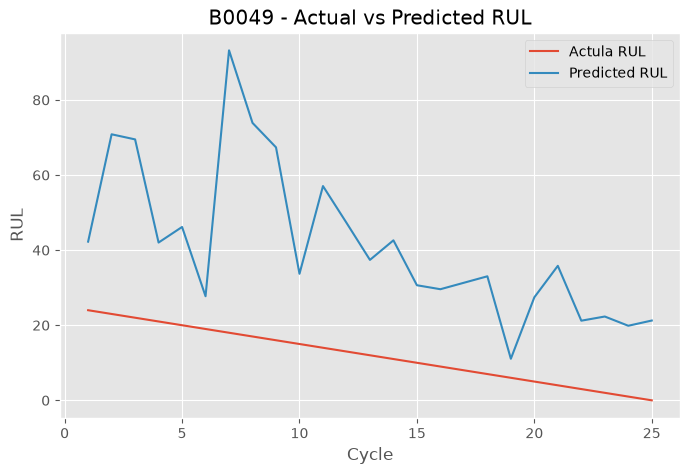

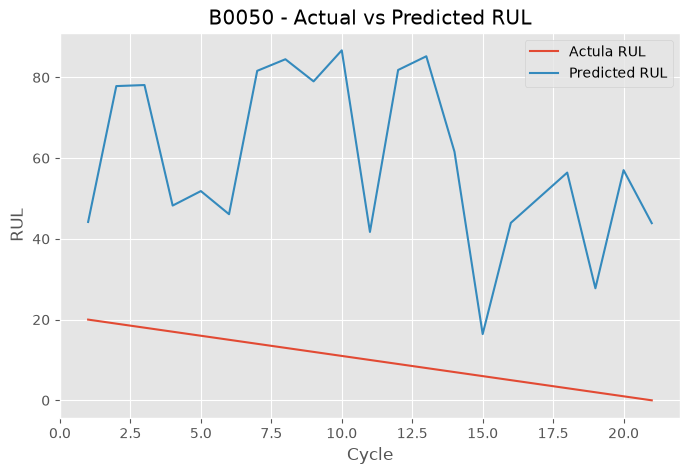

In [89]:
# Actula vs Predicted RUL for B0049 & B0050 battery

for battery in ["B0049", "B0050"]:

    battery_data = results_df[
        results_df["Battery_ID"] == battery
    ]

    plt.figure(figsize=(8, 5))

    plt.plot(
        battery_data["Cycle"],
        battery_data["RUL"],
        label="Actula RUL"
    )

    plt.plot(
        battery_data["Cycle"],
        battery_data["Predicted_RUL"],
        label="Predicted RUL"
    )

    plt.xlabel("Cycle")
    plt.ylabel("RUL")
    plt.title(f"{battery} - Actual vs Predicted RUL")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    

The B0049 prediction plot shows significant disagreement between actual and predicted RUL. While the actual RUL decreases consistently with cycle number, the model produces substantially higher and unstable predictions. This indicates that the model has difficulty generalizing to the degradation characteristics of B0049, which has a relatively short battery lifetime. This battery-specific error contributes significantly to the overall reduction in model performance.

The B0050 plot shows a substantial difference between actual and predicted RUL. The actual RUL decreases consistently with cycle number, whereas the model produces significantly higher and unstable predictions. This indicates poor generalization to the degradation characteristics of B0050. The large prediction errors from this short-lifetime battery contribute substantially to the overall reduction in model performance.

### Hyperparameter Tuning for XGBoost Using GroupKFold

In [90]:
from sklearn.model_selection import RandomizedSearchCV, GroupKFold

In [91]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

In [92]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 2, 5, 10]
}

In [93]:
group_kfold = GroupKFold(n_splits=5)

In [94]:
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=group_kfold,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [95]:
groups_train = train_df["Battery_ID"]

In [96]:
print("Training groups:", groups_train.nunique())
print(groups_train.unique())

Training groups: 27
<StringArray>
['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028',
 'B0030', 'B0031', 'B0032', 'B0033', 'B0034', 'B0036', 'B0039', 'B0040',
 'B0041', 'B0043', 'B0045', 'B0046', 'B0048', 'B0051', 'B0052', 'B0053',
 'B0054', 'B0055', 'B0056']
Length: 27, dtype: str


In [97]:
# Fit on battery groups

random_search_xgb.fit(
    X_train,
    y_train,
    groups=groups_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",GroupKFold(n_...shuffle=False)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best e

In [98]:
print("Best XGBoost Parameters:")
print(random_search_xgb.best_params_)

print("\nBest GroupKFold CV MAE:")
print(-random_search_xgb.best_score_)

Best XGBoost Parameters:
{'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

Best GroupKFold CV MAE:
14.111981964111328


In [99]:
best_xgb = random_search_xgb.best_estimator_

In [100]:
# Predict on 7 Unseen batteries

y_pred_xgb_tuned = best_xgb.predict(X_test)

In [101]:
mae_xgb_tuned = mean_absolute_error(
    y_test,
    y_pred_xgb_tuned
)

mse_xgb_tuned = mean_squared_error(
    y_test,
    y_pred_xgb_tuned
)

rmse_xgb_tuned = np.sqrt(mse_xgb_tuned)

r2_xgb_tuned = r2_score(
    y_test,
    y_pred_xgb_tuned
)

print("Tuned XGBoost - Unseen Battery Performance")
print("-" * 55)

print(f"MAE : {mae_xgb_tuned:.4f}")
print(f"MSE : {mse_xgb_tuned:.4f}")
print(f"RMSE: {rmse_xgb_tuned:.4f}")
print(f"R2  : {r2_xgb_tuned:.4f}")

Tuned XGBoost - Unseen Battery Performance
-------------------------------------------------------
MAE : 10.1798
MSE : 375.7267
RMSE: 19.3837
R2  : 0.5961


Multiple regression models and optimization approaches were evaluated using battery-wise validation. Although the initial random-split evaluation produced very high R² values, battery-wise evaluation provided a more realistic measure of generalization. Random Forest achieved the best performance on the seven completely unseen batteries, with an MAE of 9.6968 cycles, RMSE of 18.4213 cycles, and R² of 0.6352. Further hyperparameter tuning of Random Forest and XGBoost did not improve the unseen-battery performance. Therefore, the original Random Forest model was selected as the final model.

### Final Model Evaluation and Visualization

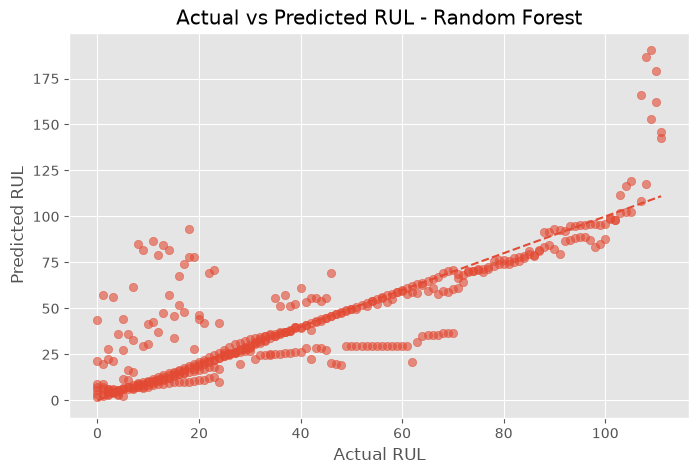

In [102]:
# Actual vs Predicted RUL

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_rf, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL - Random Forest")
plt.grid(True)
plt.show()

The Actual vs Predicted RUL plot shows that the Random Forest model captures the overall relationship between actual and predicted RUL for the unseen batteries. Most predictions follow the expected diagonal trend, particularly in the middle RUL range. However, larger deviations are observed at very low and high RUL values, indicating difficulty in generalizing to certain battery degradation patterns.

In [103]:
# Residual/Error Analysis

residuals = y_test - y_pred_rf

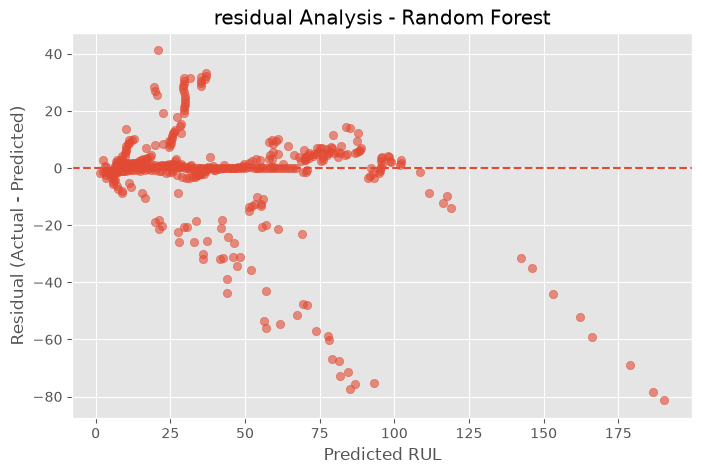

In [104]:
plt.figure(figsize=(8, 5))

plt.scatter(y_pred_rf, residuals, alpha=0.6)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted RUL")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("residual Analysis - Random Forest")
plt.grid(True)
plt.show()

The residual analysis shows that most predictions have relatively small errors around zero, indicating good performance for a significant portion of the test samples. However, larger negative residuals are observed at higher predicted RUL values, indicating that the model tends to overestimate RUL for some batteries. The non-random distribution and increasing spread of residuals indicate that prediction accuracy varies across the RUL range and that battery-specific degradation behavior remains a challenge.

### Feature Importance

In [105]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(feature_importance)

Discharge_Time     0.604833
Avg_Current        0.209488
Cycle              0.099707
Avg_Temperature    0.045007
Avg_Voltage        0.027750
Capacity           0.013214
dtype: float64


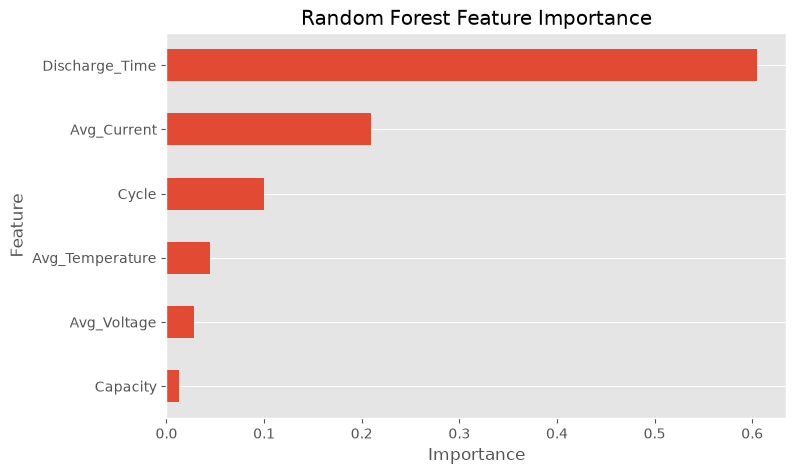

In [106]:
# Plot

plt.figure(figsize=(8, 5))

feature_importance.sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.grid(axis="x")
plt.show()

The feature-importance analysis shows that Discharge_Time is the most influential feature for RUL prediction, followed by Avg_Current and Cycle. Avg_Temperature, Avg_Voltage, and Capacity have comparatively lower importance. This indicates that discharge behavior and operating characteristics provide strong predictive information about the remaining useful life of the batteries.

In [107]:
# Save the Model

import joblib

joblib.dump(rf_model, "battery_rul_random_forest.pkl")

print("Final Random Forest model saved successfully.")

Final Random Forest model saved successfully.


In [108]:
import os

print(os.path.exists("battery_rul_random_forest.pkl"))

True


The final Random Forest model was saved using Joblib so that the trained model can be reused for future RUL predictions without retraining.

In [110]:
# Load the model

model = joblib.load("battery_rul_random_forest.pkl")

print("Model loaded successfully!")
print(model)

Model loaded successfully!
RandomForestRegressor(n_jobs=-1, random_state=42)


In [111]:
# verify

y_pred_loaded = model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred_loaded[:10])

Predictions generated successfully!
[39.81 37.88 37.23 36.66 36.05 35.47 34.94 34.29 33.68 33.1 ]


### Prediction for new-battery

In [112]:
features = [
    "Cycle",
    "Capacity",
    "Avg_Voltage",
    "Avg_Current",
    "Avg_Temperature",
    "Discharge_Time"
]

In [113]:
# Create new battery

new_battery = pd.DataFrame({
    "Cycle": [10],
    "Capacity": [1.82],
    "Avg_Voltage": [3.54],
    "Avg_Current": [-1.82],
    "Avg_Temperature": [32.5],
    "Discharge_Time": [3600]
})

predicted_rul = model.predict(new_battery)

print(f"Predicted RUL: {predicted_rul[0]:.2f} cycles")
    

Predicted RUL: 157.54 cycles


A sample prediction was performed using the saved Random Forest model. Given a set of battery operating measurements, the model predicted a remaining useful life of approximately 157.54 cycles. This demonstrates how the trained model can be reused to estimate RUL for new battery observations.

## Final Model Selection

Although XGBoost produced a higher R² during the initial evaluation, that evaluation used a row-wise split, where data from the same battery could appear in both training and testing. Since consecutive cycles from the same battery are highly related, this can lead to data leakage and an overly optimistic performance estimate.

To obtain a more realistic evaluation, the dataset was divided at the battery level. 27 batteries were used for training and 7 completely unseen batteries were reserved for final testing. GroupKFold was also used during validation to ensure that samples from the same battery were never divided between training and validation folds.

Under this battery-wise evaluation, Random Forest achieved the best performance:

- MAE: 9.6968 cycles
- RMSE: 18.4213 cycles
- R²: 0.6352

XGBoost achieved an R² of 0.6174, while tuned XGBoost achieved 0.5961 on the unseen batteries.

Therefore, Random Forest was selected as the final model because it provided the best generalization performance on completely unseen batteries rather than relying on the artificially high score from the earlier row-wise evaluation.

# Conclusion

This project developed a machine learning-based approach for predicting the Remaining Useful Life (RUL) of lithium-ion batteries using battery cycling and operating characteristics.

The NASA battery aging dataset was processed to extract cycle-level features including capacity, average voltage, average current, average temperature, and discharge time. Additional capacity-based features were also explored during feature engineering.

To obtain a realistic estimate of model generalization, the data was split at the battery level. 27 batteries were used for training and 7 completely unseen batteries were reserved for final testing. GroupKFold cross-validation was used during model development to prevent samples from the same battery appearing in both training and validation sets.

Several regression models were evaluated, including Linear Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, and Extra Trees. Random Forest provided the best performance on the unseen batteries.

### Final Model Performance

- MAE: 9.6968 cycles
- RMSE: 18.4213 cycles
- R²: 0.6352

Battery-wise error analysis showed that the model performed very well on some unseen batteries but struggled with batteries having different or very short degradation patterns. In particular, B0049 and B0050 produced large prediction errors.

Feature-importance analysis showed that Discharge_Time was the most influential feature, followed by Avg_Current and Cycle.

The final Random Forest model was saved as `battery_rul_random_forest.pkl` and successfully used to generate RUL predictions for new battery measurements.

Overall, the project demonstrates that machine learning can capture useful degradation patterns for battery RUL prediction, while also highlighting the challenge of generalizing across batteries with different aging characteristics.